# Imports

In [336]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [337]:
import numpy as np
import matplotlib.pyplot as plt

In [338]:
import cv2

# Methods

In [396]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shift) + 1) # 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum, f_shift


In [ ]:
def box_blur_manual(img, ksize=(3, 3)):
    # Tamanho do kernel
    k_h, k_w = ksize
    pad_h = k_h // 2
    pad_w = k_w // 2

    # Cria uma cópia da imagem com padding (borda replicada)
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    # Cria a imagem de saída
    output = np.zeros_like(img, dtype=np.uint8)

    # Aplica o filtro manualmente
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + k_h, j:j + k_w]
            mean_val = np.mean(region)
            output[i, j] = int(mean_val)

    return output

# Parameters

In [340]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 09

## a) uma solução aplicada no domínio da frequência

### 1.1) Leitura

In [341]:
img_names = ["cameraman.png", "cameraman_pattern.png"]
# img = cv2.imread(path_assets / "atv02_lista02-assets" / 'cameraman_pattern.png', cv2.IMREAD_GRAYSCALE)
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

# imgs["cameraman_pattern_cut"] = imgs["cameraman_pattern"][0:150, 0:200]

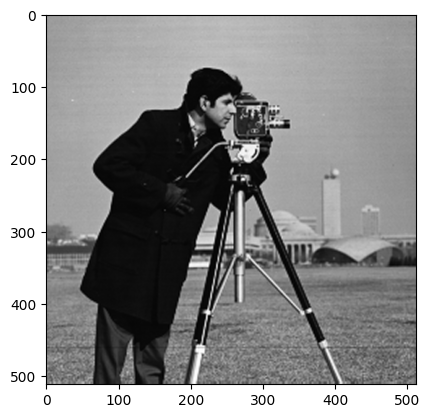

In [342]:
# Aplicando a transformada de Fourier
dft = cv2.dft(np.float32(imgs["cameraman"]), flags=cv2.DFT_COMPLEX_OUTPUT)

# Deslocando o zero-frequência para o centro
dft_shift = np.fft.fftshift(dft)
dft_ishift = np.fft.ifftshift(dft_shift)
img_back = cv2.idft(dft_ishift)
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
plt.imshow(img_back, cmap='gray')

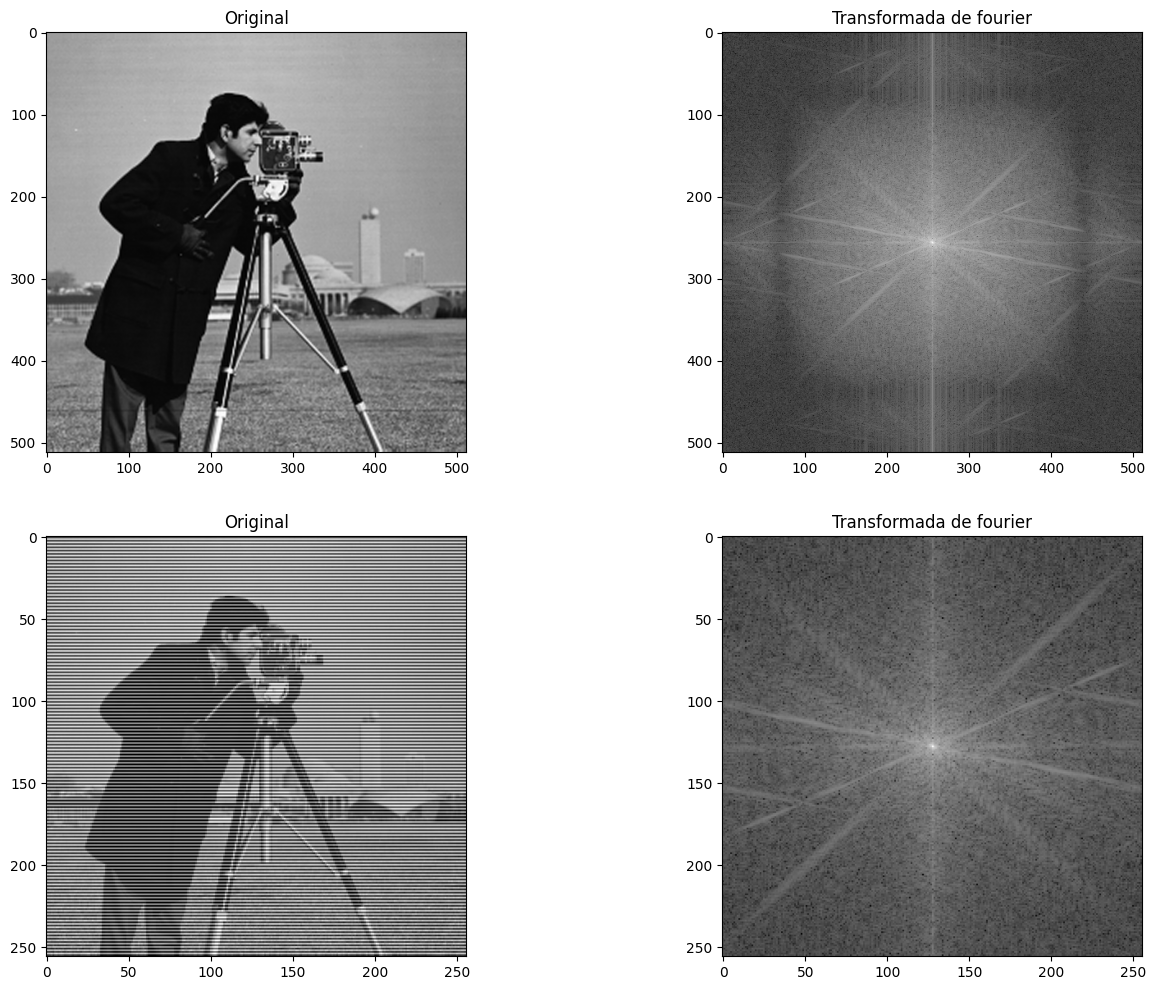

In [343]:
fourier = {
    name: {
        "tft": apply_fourier_transform(img)[1],
        "spectrum": apply_fourier_transform(img)[0]
    } for name, img in imgs.items()
}
# Mostrar imagem resultante
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 12))
for _ax, name in zip(ax, fourier.keys()):
    _ax[0].imshow(imgs[name], cmap='gray')
    _ax[0].set_title('Original')
    _ax[1].imshow(fourier[name]["spectrum"].astype(float), cmap='gray')
    _ax[1].set_title('Transformada de fourier')
    #_ax[0].axis('off')
    #_ax[1].axis('off')
plt.show()


In [344]:
# recorte = imgs["cameraman_pattern"]
# for i in range(1, recorte.shape[0], 2):
#     print(recorte[i]) 
#     recorte[i] = recorte[i - 1]#[np.median(recorte)] * recorte.shape[1]
#     # recorte[i] = [255] * recorte.shape[1]

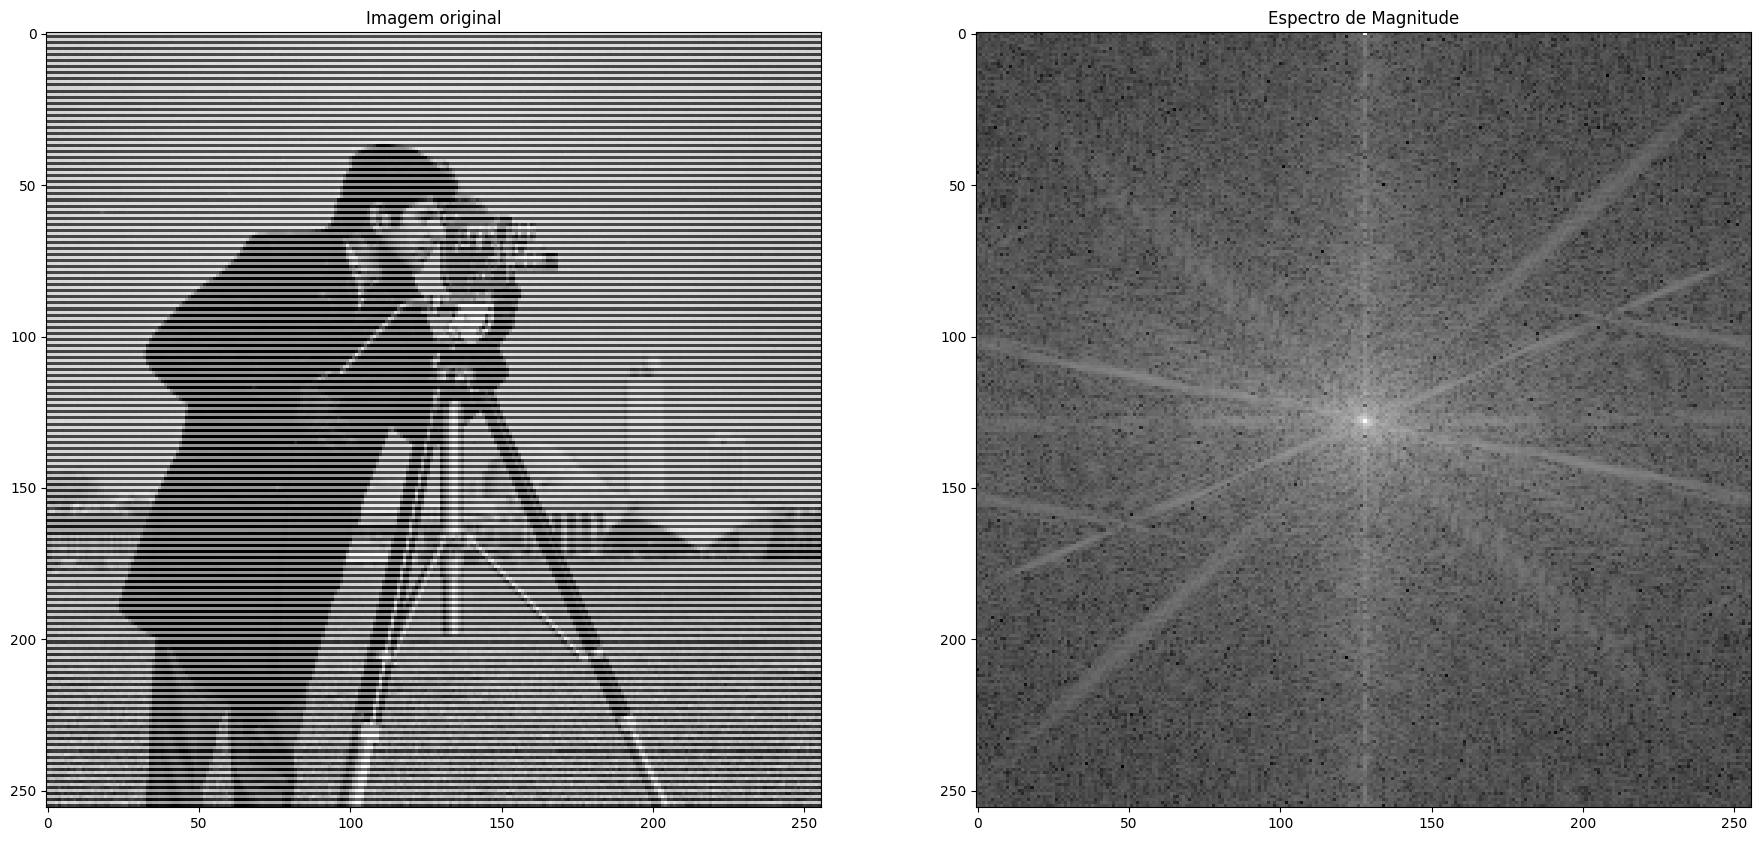

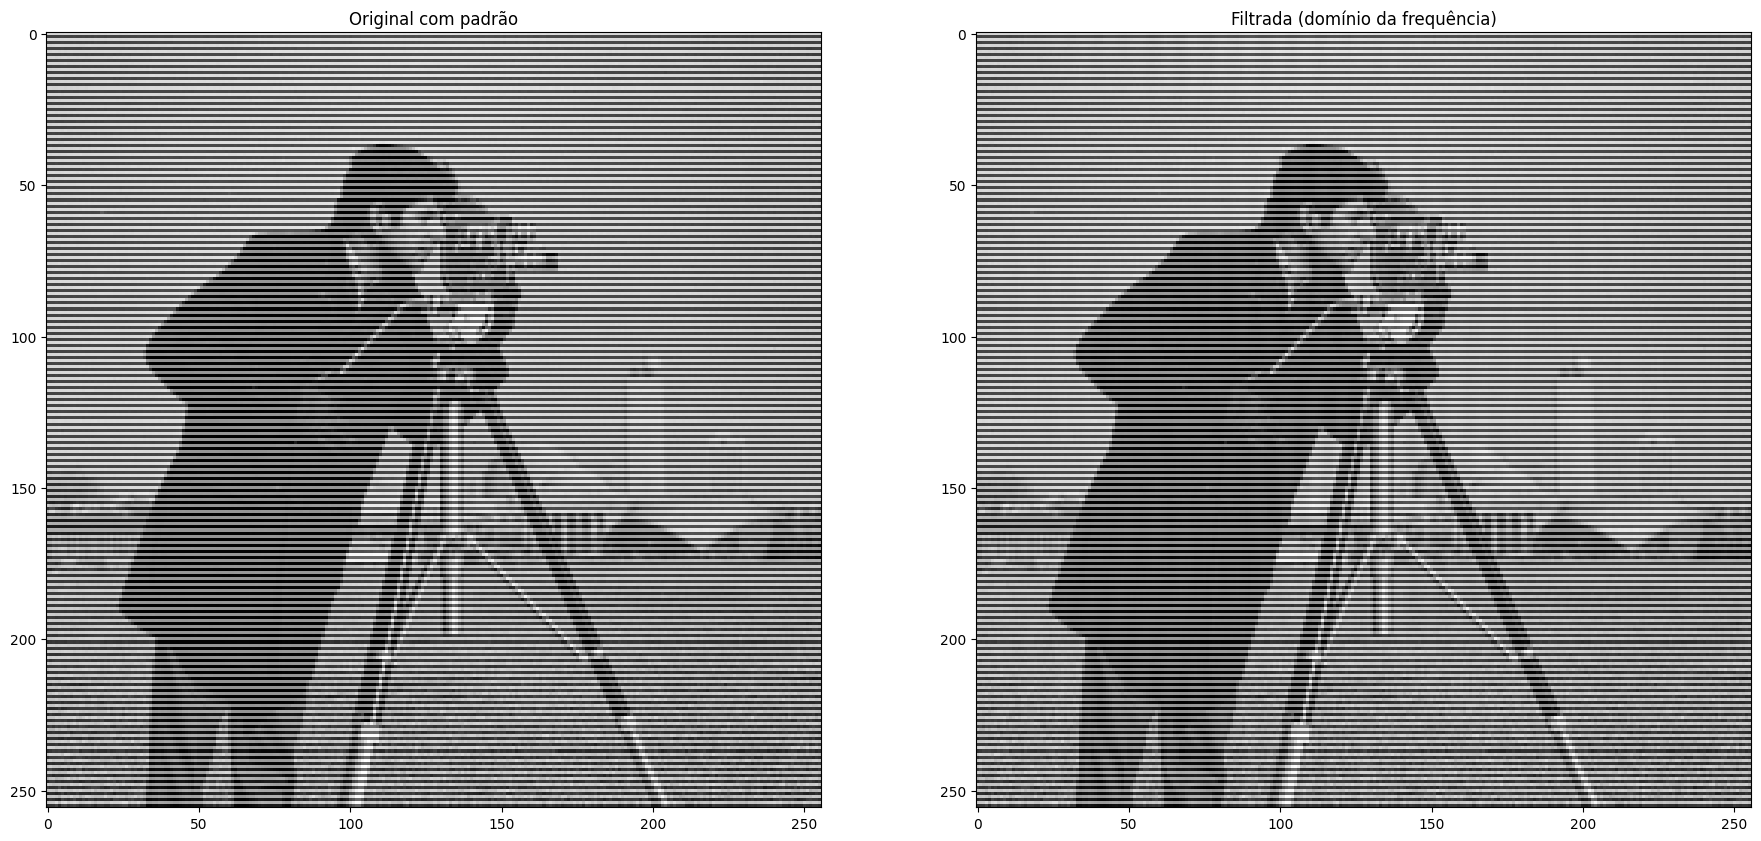

In [345]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar a imagem com padrão
img = imgs["cameraman_pattern"].astype(np.float32)

# 1. Aplicar FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = np.log(1 + np.abs(fshift))

# 2. Visualizar espectro de magnitude para identificar os picos
plt.figure(figsize=(22, 18))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Imagem original')
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Espectro de Magnitude')
plt.show()

# 3. Criar uma máscara para remover os picos indesejados
rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2

# Cria uma máscara com 1s (deixa tudo) e 0s nos pontos a serem removidos
mask = np.ones((rows, cols), np.uint8)
# Exemplo: remover pequenas regiões em torno de onde os picos aparecem
mask[crow-3:crow+3, ccol-30:ccol-25] = 0
mask[crow-3:crow+3, ccol+25:ccol+30] = 0

# 4. Aplicar a máscara
fshift_filtered = fshift * mask

# 5. Transformada inversa
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Mostrar imagem final
plt.figure(figsize=(22, 18))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original com padrão')
plt.subplot(122), plt.imshow(img_filtered, cmap='gray'), plt.title('Filtrada (domínio da frequência)')
plt.show()


In [346]:

mask = np.ones_like(fshift, dtype=np.uint8)

# Tentar remover regiões diagonais e verticais perto de onde aparecem os riscos
# Ajuste esses valores manualmente de acordo com os picos que você vê

# Exemplo: eliminar linha vertical passando pelo centro (típica de padrão horizontal)
mask[:, 127:129] = 0  # ajustado ao redor do centro
# Exemplo: eliminar algumas diagonais — cuidado para não destruir a imagem
# for offset in range(0, 41, 1):
#     if offset == 0:
#         continue
#     mask[128+offset, :] = 0
#     mask[:, 128+offset] = 0


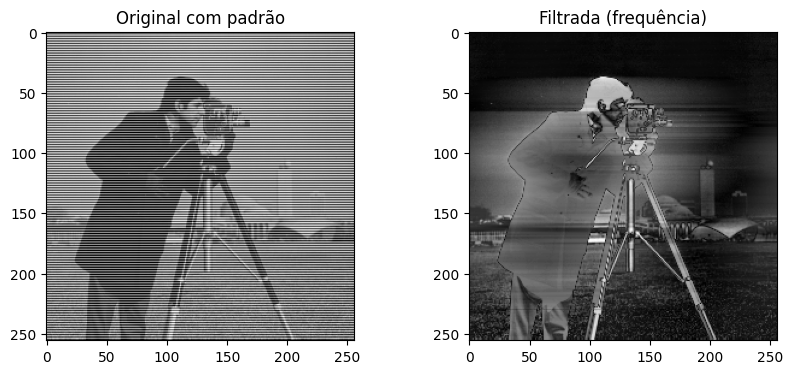

In [347]:
fshift_filtered = fshift * mask
# Transformada inversa
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Exibir o resultado
plt.figure(figsize=(10, 4))
plt.subplot(121), plt.imshow(imgs["cameraman_pattern"], cmap='gray'), plt.title("Original com padrão")
plt.subplot(122), plt.imshow(img_filtered, cmap='gray'), plt.title("Filtrada (frequência)")
plt.show()

## b) uma solução aplicada no domínio espacial

Vamos aplicar um filtro box considerando uma vizinhança 2x2 e também um filtro gaussiano, com &sigma; = 1, para ver qual método consegue recuperar melhor a imagem original.

In [ ]:
filtered_img = {
    "Filtro box 2x2": cv2.blur(imgs["cameraman_pattern"], (2, 2)),  # aplicando um filtro box de dimensão 2x2
    "Filtro gaussiano": cv2.GaussianBlur(
        imgs["cameraman_pattern"],
        (0, 0),
        sigmaX=1,
        sigmaY=1
    ) # Aplicando um filtro gaussiano, com sigma = 1
}
# filtered_img = cv2.GaussianBlur(imgs["cameraman_pattern"], (3, 3), 1)
# filtered_img = box_blur_manual(imgs["cameraman_pattern"], ksize=(2, 2))

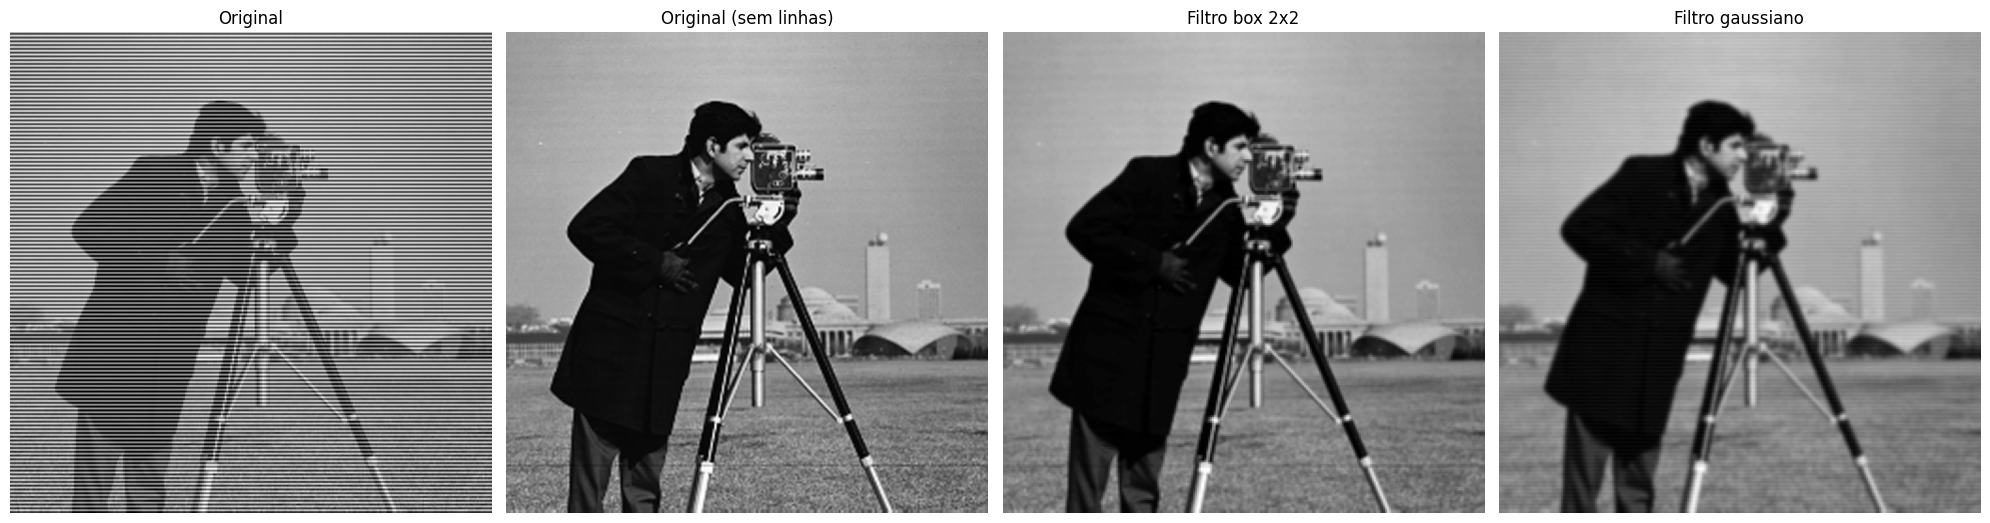

In [404]:
fig, ax = plt.subplots(1, len(filtered_img.keys()) + 2, figsize=(20, 10))
ax[0].set_title('Original')
ax[0].imshow(imgs["cameraman_pattern"], cmap='gray')
ax[0].axis('off')

ax[1].set_title('Original (sem linhas)')
ax[1].imshow(imgs["cameraman"], cmap='gray')
ax[1].axis('off')

for _ax, (title, content) in zip(ax[2:], filtered_img.items()):
    _ax.imshow(content, cmap='gray')
    _ax.set_title(title)
    _ax.axis('off')
fig.tight_layout()
fig.savefig(path_assets / "atv02-q09-01.png", dpi=400, bbox_inches='tight')
plt.show()


### Conclusão

Ambos os filtros aplicados conseguiram sumir com as linhas existentes na imagem, porém ambos ainda sim causando um efeito de borramento, como era esperado de ambos. Para esse cenário especifico, o filtro box 2x2 conseguiu recuperar com mais detalhes, menos borrado quando comparado ao filtro gaussiano, não sendo tão fiel aos detalhes original.